Saving 3640322279678e635c3303f83c090769.jpg to 3640322279678e635c3303f83c090769.jpg


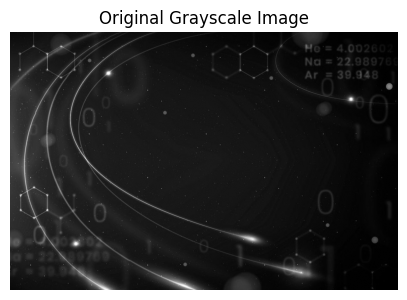

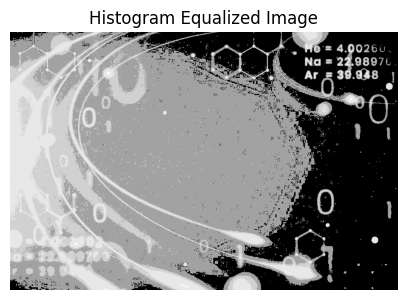

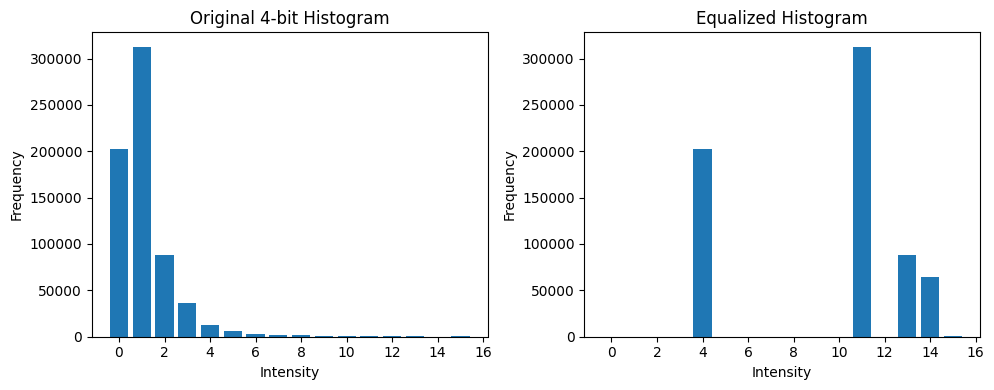

Original Histogram:
[201945 312637  87715  36303  12174   5807   2987   2120   1499   1071
    803    619    557    322    195    246]

Equalized Histogram:
[     0      0      0      0 201945      0      0      0      0      0
      0 312637      0  87715  64457    246]

Transformation Function:
[ 4 11 13 14 14 14 14 14 14 14 14 14 14 14 14 15]


In [ ]:
# Experiment 1
# Manual Histogram Equalization on a 4-bit Sample Image Matrix

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Read uploaded image
image_path = list(uploaded.keys())[0]

# Read as grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Display Original Image
plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

# ----------------------------
# Convert to 4-bit Image (0-15)
# ----------------------------
img4 = img // 16

L = 16   # Number of intensity levels (4-bit)

# Step 1: Histogram
hist = np.zeros(L, dtype=int)

for pixel in img4.flatten():
    hist[pixel] += 1

# Step 2: Probability Distribution
total_pixels = img4.size
pdf = hist / total_pixels

# Step 3: Cumulative Distribution Function
cdf = np.cumsum(pdf)

# Step 4: Transformation Function
transform = np.floor((L - 1) * cdf).astype(np.uint8)

# Step 5: Equalized Image
equalized4 = transform[img4]

# Convert back to 8-bit for display
equalized8 = equalized4 * 17

# Display Equalized Image
plt.figure(figsize=(5,5))
plt.imshow(equalized8, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis('off')
plt.show()

# ----------------------------
# Display Histograms
# ----------------------------

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(range(L), hist)
plt.title("Original 4-bit Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

hist_eq = np.zeros(L, dtype=int)

for pixel in equalized4.flatten():
    hist_eq[pixel] += 1

plt.subplot(1,2,2)
plt.bar(range(L), hist_eq)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print Histogram Values
print("Original Histogram:")
print(hist)

print("\nEqualized Histogram:")
print(hist_eq)

print("\nTransformation Function:")
print(transform)

Saving block diagram.png to block diagram.png


/tmp/ipykernel_641/1779677133.py:31: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(gray))
/tmp/ipykernel_641/1779677133.py:31: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(gray))


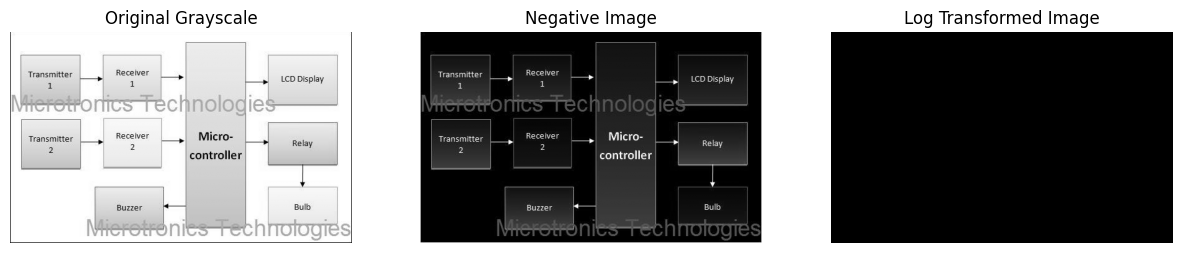

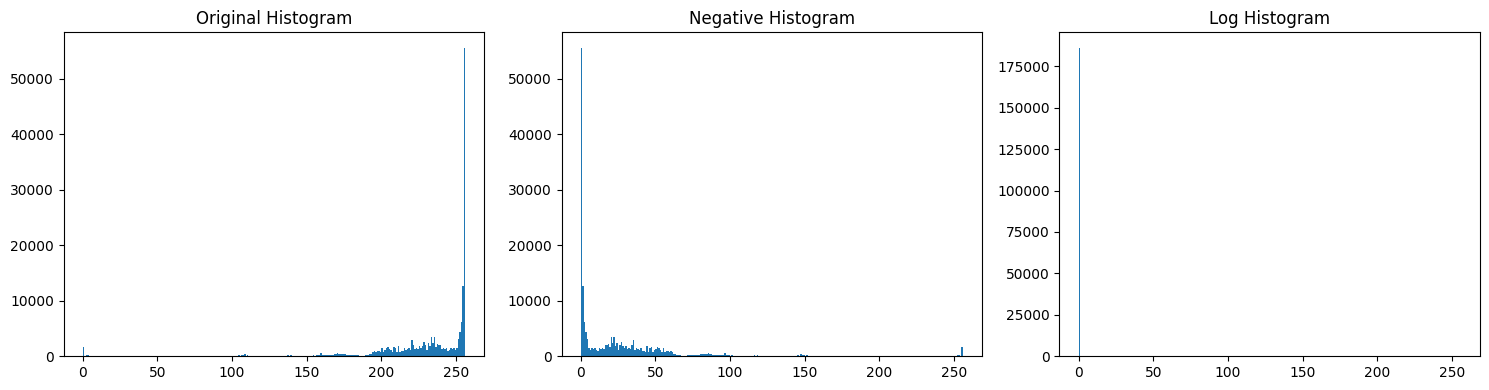

Negative Transformation Formula:
s = 255 - r

Log Transformation Formula:
s = c × log(1 + r)


In [ ]:
# Experiment 2
# Negative and Log Transformations on a Grayscale Image

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload Image
uploaded = files.upload()

# Read uploaded image
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Negative Transformation
# s = 255 - r
# -----------------------------
negative = 255 - gray

# -----------------------------
# Log Transformation
# s = c * log(1 + r)
# -----------------------------
c = 255 / np.log(1 + np.max(gray))
log_image = c * np.log(1 + gray.astype(np.float32))
log_image = np.array(log_image, dtype=np.uint8)

# -----------------------------
# Display Images
# -----------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(negative, cmap='gray')
plt.title("Negative Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(log_image, cmap='gray')
plt.title("Log Transformed Image")
plt.axis('off')

plt.show()

# -----------------------------
# Display Histograms
# -----------------------------
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

plt.subplot(1,3,2)
plt.hist(negative.ravel(), bins=256, range=[0,256])
plt.title("Negative Histogram")

plt.subplot(1,3,3)
plt.hist(log_image.ravel(), bins=256, range=[0,256])
plt.title("Log Histogram")

plt.tight_layout()
plt.show()

print("Negative Transformation Formula:")
print("s = 255 - r")

print("\nLog Transformation Formula:")
print("s = c × log(1 + r)")

Saving deep-fake-news-artificial-intelligence-260nw-2442838257.webp to deep-fake-news-artificial-intelligence-260nw-2442838257.webp


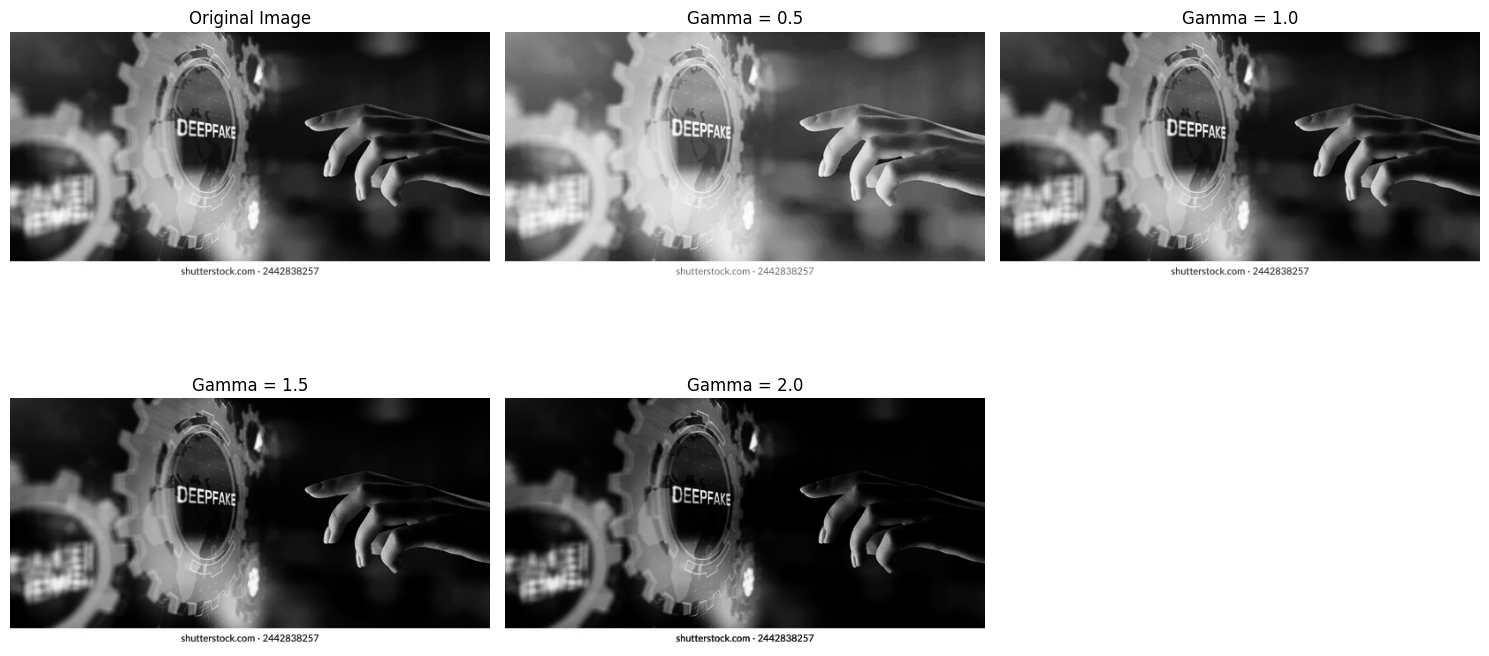

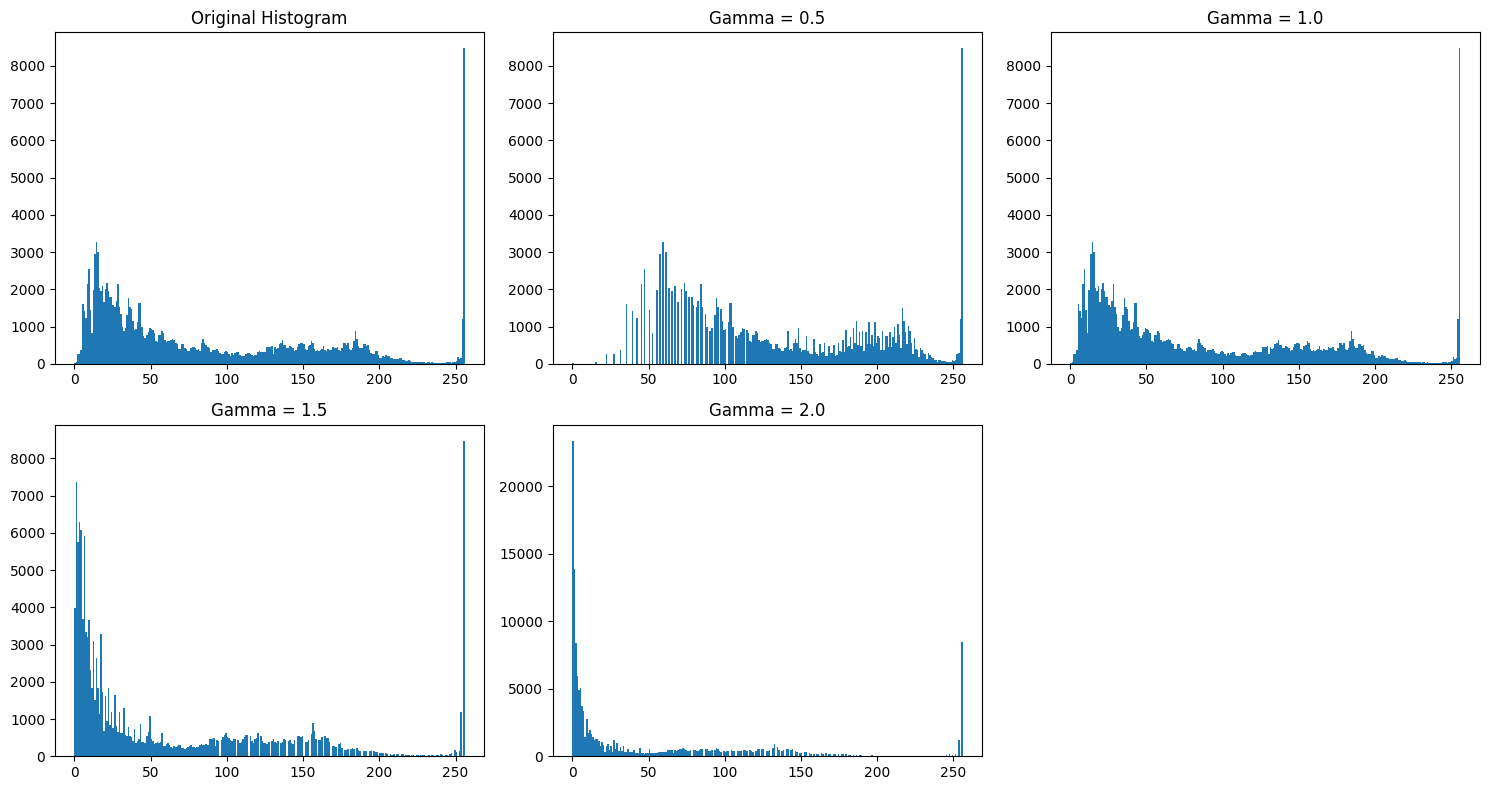

Power-Law (Gamma) Transformation Formula:
s = c × r^γ

where
s = Output intensity
r = Input intensity
γ = Gamma value
c = Constant (taken as 1)


In [ ]:
# Experiment 3
# Power-Law (Gamma) Transformation

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload Image
uploaded = files.upload()

# Read uploaded image
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Normalize image (0 to 1)
gray_norm = gray / 255.0

# Gamma values
gamma_values = [0.5, 1.0, 1.5, 2.0]

# Display Original Image
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Apply Gamma Transformation
for i, gamma in enumerate(gamma_values):

    gamma_corrected = np.power(gray_norm, gamma)

    gamma_corrected = np.uint8(gamma_corrected * 255)

    plt.subplot(2,3,i+2)
    plt.imshow(gamma_corrected, cmap='gray')
    plt.title(f"Gamma = {gamma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Plot Histograms
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

for i, gamma in enumerate(gamma_values):

    gamma_corrected = np.power(gray_norm, gamma)
    gamma_corrected = np.uint8(gamma_corrected * 255)

    plt.subplot(2,3,i+2)
    plt.hist(gamma_corrected.ravel(), bins=256, range=[0,256])
    plt.title(f"Gamma = {gamma}")

plt.tight_layout()
plt.show()

print("Power-Law (Gamma) Transformation Formula:")
print("s = c × r^γ")
print("\nwhere")
print("s = Output intensity")
print("r = Input intensity")
print("γ = Gamma value")
print("c = Constant (taken as 1)")

Saving 5255a00b-bfbf-4be5-8759-3538ba54c27e.jpg to 5255a00b-bfbf-4be5-8759-3538ba54c27e.jpg


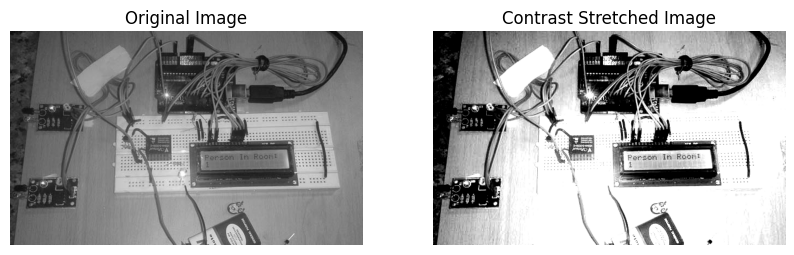

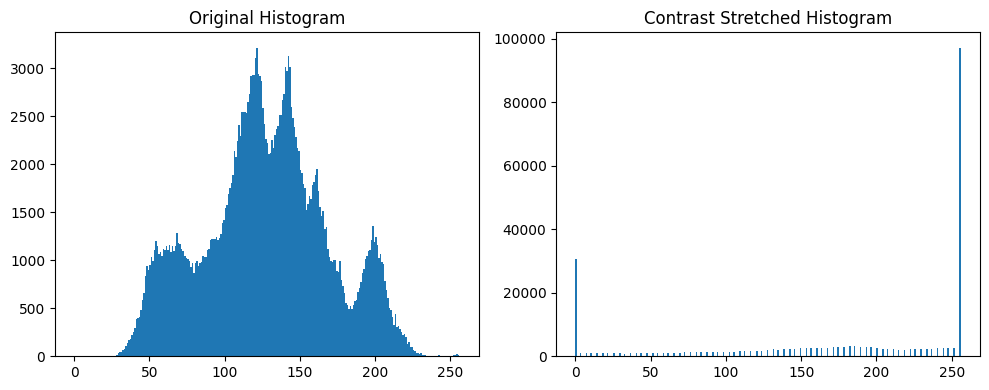

Piecewise Linear Contrast Stretching
------------------------------------
r1 = 70, s1 = 0
r2 = 140, s2 = 255


In [ ]:
# Experiment 4
# Piecewise-Linear Contrast Stretching

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload Image
uploaded = files.upload()

# Read uploaded image
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Piecewise Linear Contrast Stretching
# -----------------------------

# Input breakpoints
r1 = 70
s1 = 0

r2 = 140
s2 = 255

# Output image
stretched = np.zeros_like(gray)

rows, cols = gray.shape

for i in range(rows):
    for j in range(cols):

        r = gray[i, j]

        if r <= r1:
            stretched[i, j] = (s1 / r1) * r if r1 != 0 else 0

        elif r <= r2:
            stretched[i, j] = ((s2 - s1) / (r2 - r1)) * (r - r1) + s1

        else:
            stretched[i, j] = ((255 - s2) / (255 - r2)) * (r - r2) + s2 if r2 != 255 else 255

stretched = stretched.astype(np.uint8)

# -----------------------------
# Display Images
# -----------------------------

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(stretched, cmap='gray')
plt.title("Contrast Stretched Image")
plt.axis("off")

plt.show()

# -----------------------------
# Histograms
# -----------------------------

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(stretched.ravel(), bins=256, range=[0,256])
plt.title("Contrast Stretched Histogram")

plt.tight_layout()
plt.show()

# -----------------------------
# Print Parameters
# -----------------------------

print("Piecewise Linear Contrast Stretching")
print("------------------------------------")
print(f"r1 = {r1}, s1 = {s1}")
print(f"r2 = {r2}, s2 = {s2}")

Saving deepfakes-blog1a-social-1200x630.jpg to deepfakes-blog1a-social-1200x630.jpg


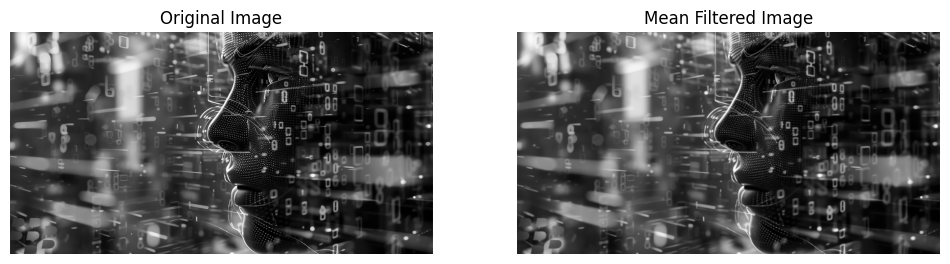

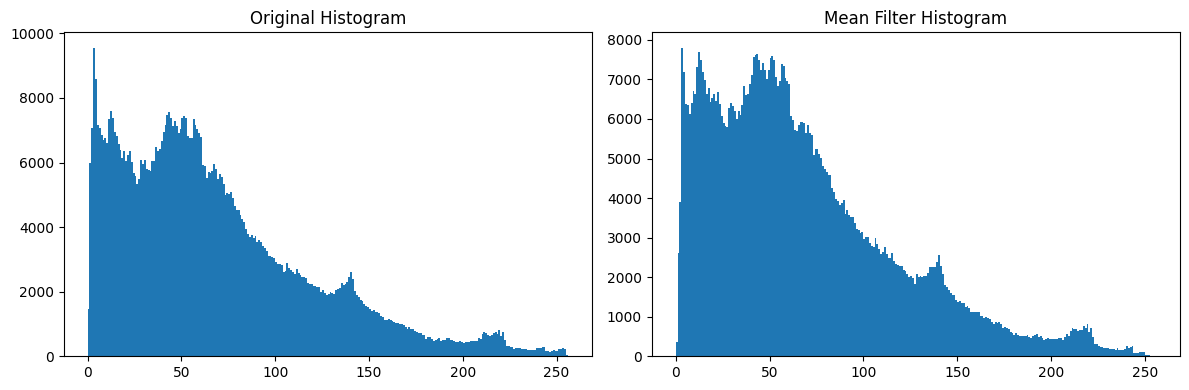

3 × 3 Mean Filter Kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


In [ ]:
# Experiment 5
# Mean (Averaging) Filter

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Read uploaded image
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Mean Filter (3x3)
# -----------------------------
kernel = np.ones((3,3), np.float32) / 9

mean_filtered = cv2.filter2D(gray, -1, kernel)

# -----------------------------
# Display Images
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mean_filtered, cmap='gray')
plt.title("Mean Filtered Image")
plt.axis('off')

plt.show()

# -----------------------------
# Display Histograms
# -----------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(mean_filtered.ravel(), bins=256, range=[0,256])
plt.title("Mean Filter Histogram")

plt.tight_layout()
plt.show()

# -----------------------------
# Kernel Used
# -----------------------------
print("3 × 3 Mean Filter Kernel:")
print(kernel)

Saving 3640322279678e635c3303f83c090769.jpg to 3640322279678e635c3303f83c090769 (1).jpg


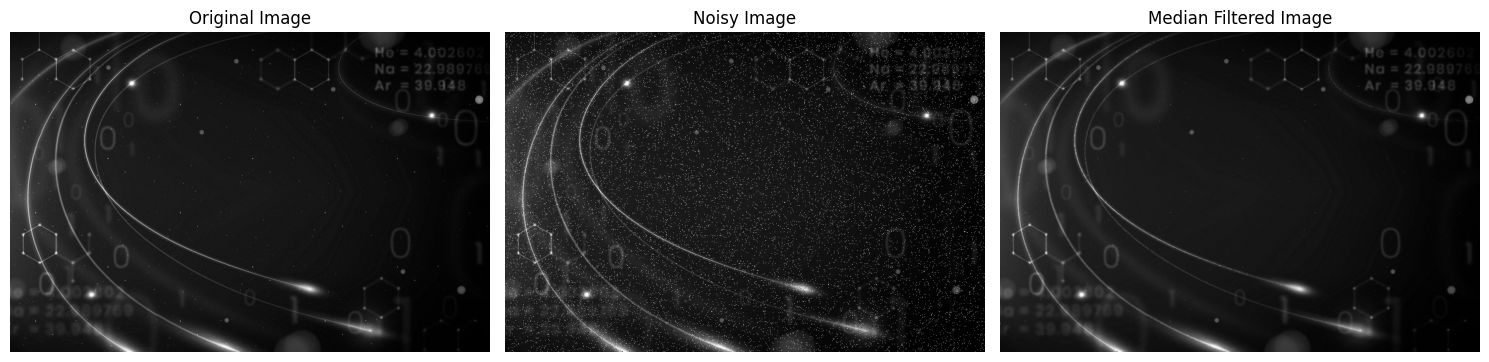

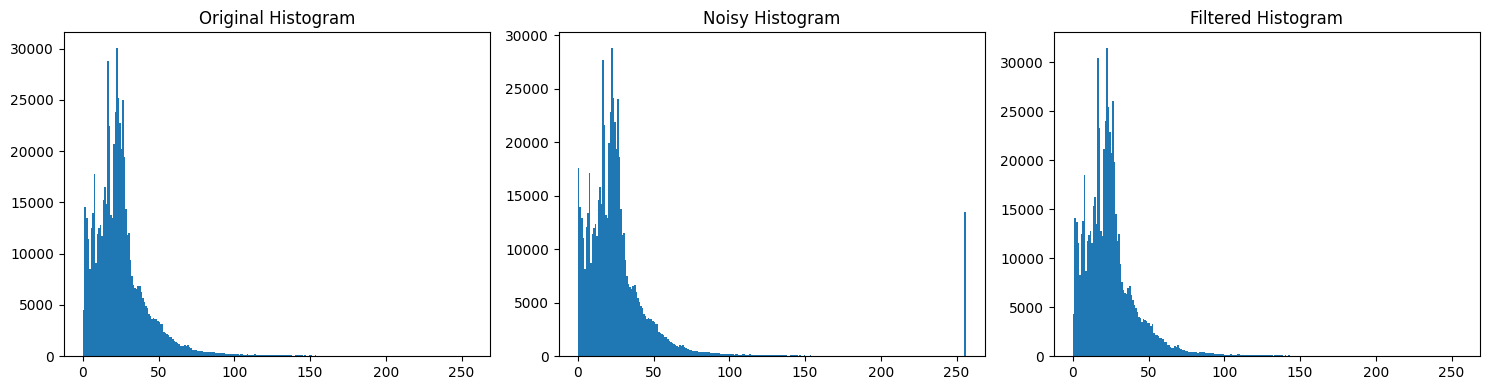

Median Filter Kernel Size: 3 × 3
Noise Type: Salt-and-Pepper


In [ ]:
# Experiment 6
# Median Filter for Salt-and-Pepper Noise Removal

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload Image
uploaded = files.upload()

# Read uploaded image
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------------
# Add Salt-and-Pepper Noise
# -----------------------------------
noisy = gray.copy()

prob = 0.02  # Noise probability

random = np.random.rand(*gray.shape)

# Pepper noise
noisy[random < prob] = 0

# Salt noise
noisy[random > 1 - prob] = 255

# -----------------------------------
# Apply Median Filter
# -----------------------------------
median_filtered = cv2.medianBlur(noisy, 3)

# -----------------------------------
# Display Images
# -----------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(median_filtered, cmap='gray')
plt.title("Median Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# -----------------------------------
# Display Histograms
# -----------------------------------
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

plt.subplot(1,3,2)
plt.hist(noisy.ravel(), bins=256, range=[0,256])
plt.title("Noisy Histogram")

plt.subplot(1,3,3)
plt.hist(median_filtered.ravel(), bins=256, range=[0,256])
plt.title("Filtered Histogram")

plt.tight_layout()
plt.show()

print("Median Filter Kernel Size: 3 × 3")
print("Noise Type: Salt-and-Pepper")

Saving 3640322279678e635c3303f83c090769.jpg to 3640322279678e635c3303f83c090769 (2).jpg


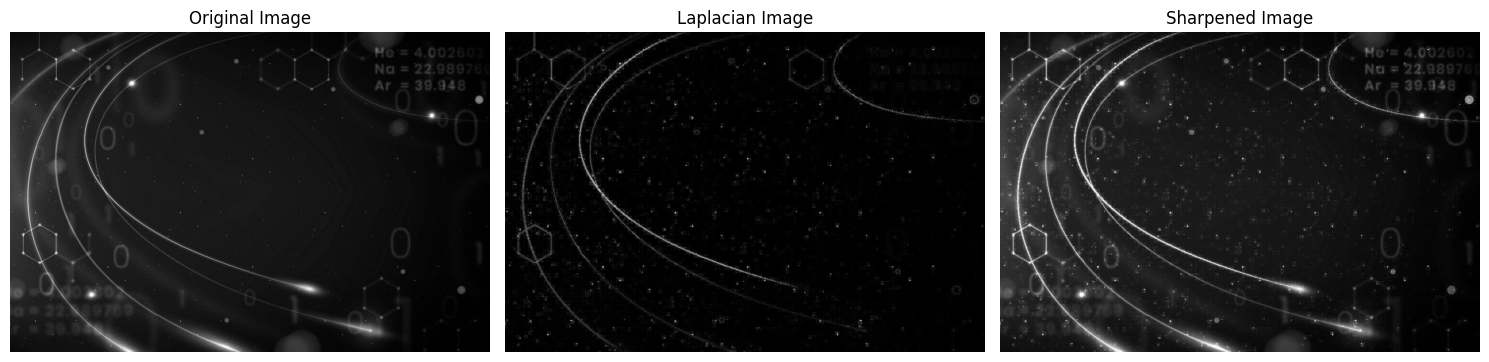

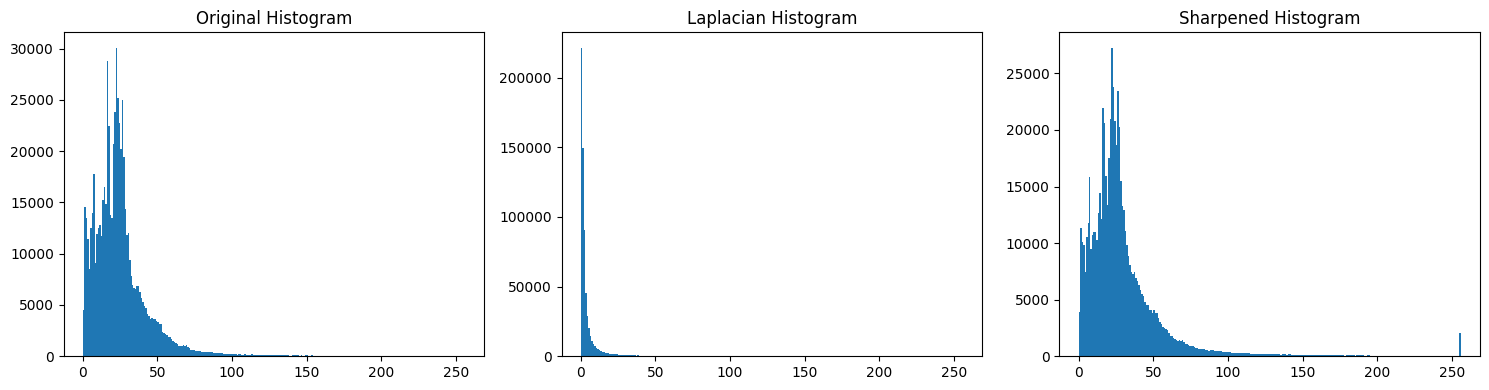

Laplacian Kernel Used:
[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]


In [ ]:
# Experiment 7
# Image Sharpening Using Laplacian Filter

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload Image
uploaded = files.upload()

# Read uploaded image
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------------
# Apply Laplacian Filter
# -----------------------------------
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# Convert to uint8
laplacian_abs = cv2.convertScaleAbs(laplacian)

# Sharpen the image
sharpened = cv2.addWeighted(gray, 1.0, laplacian_abs, 1.0, 0)

# -----------------------------------
# Display Images
# -----------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(laplacian_abs, cmap='gray')
plt.title("Laplacian Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened Image")
plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------------
# Display Histograms
# -----------------------------------
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

plt.subplot(1,3,2)
plt.hist(laplacian_abs.ravel(), bins=256, range=[0,256])
plt.title("Laplacian Histogram")

plt.subplot(1,3,3)
plt.hist(sharpened.ravel(), bins=256, range=[0,256])
plt.title("Sharpened Histogram")

plt.tight_layout()
plt.show()

print("Laplacian Kernel Used:")
print(np.array([[0, 1, 0],
                [1,-4, 1],
                [0, 1, 0]]))

Saving 8688974d8eb70cbc521a4af64e0d927b.jpg to 8688974d8eb70cbc521a4af64e0d927b.jpg


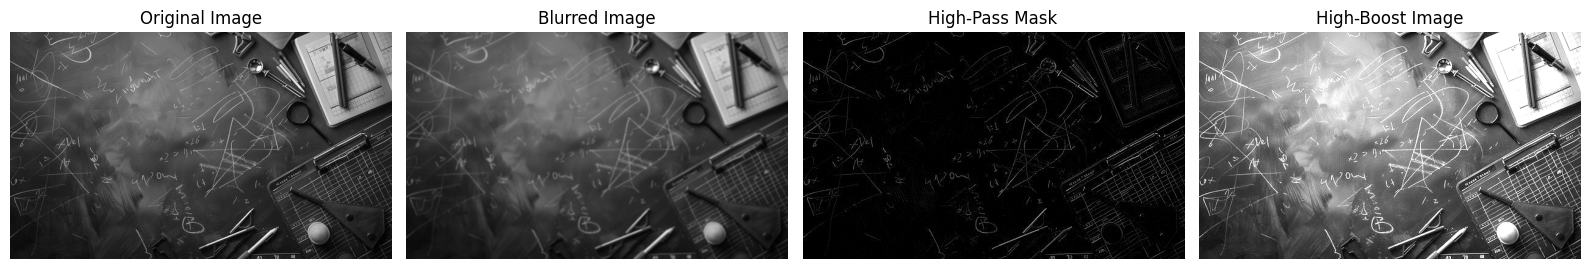

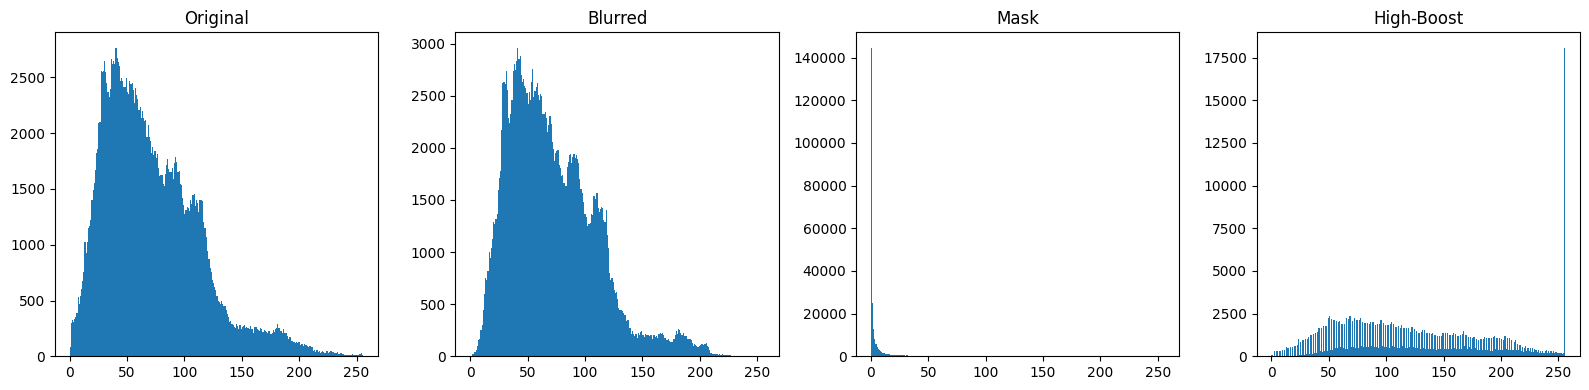

High-Boost Filtering
--------------------
High-Boost Factor (A): 1.8

Formula:
High-Boost Image = A × Original + (Original - Blurred)


In [ ]:
# Experiment 8
# High-Boost Filtering

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload Image
uploaded = files.upload()

# Read uploaded image
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------------
# Step 1: Blur the image
# -----------------------------------
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# -----------------------------------
# Step 2: Create High-Pass Mask
# -----------------------------------
mask = cv2.subtract(gray, blurred)

# -----------------------------------
# Step 3: High-Boost Filtering
# A = High-Boost Factor (A > 1)
# -----------------------------------
A = 1.8

high_boost = cv2.addWeighted(gray, A, mask, 1, 0)

# -----------------------------------
# Display Images
# -----------------------------------
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(blurred, cmap='gray')
plt.title("Blurred Image")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(mask, cmap='gray')
plt.title("High-Pass Mask")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(high_boost, cmap='gray')
plt.title("High-Boost Image")
plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------------
# Histograms
# -----------------------------------
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Original")

plt.subplot(1,4,2)
plt.hist(blurred.ravel(), bins=256, range=[0,256])
plt.title("Blurred")

plt.subplot(1,4,3)
plt.hist(mask.ravel(), bins=256, range=[0,256])
plt.title("Mask")

plt.subplot(1,4,4)
plt.hist(high_boost.ravel(), bins=256, range=[0,256])
plt.title("High-Boost")

plt.tight_layout()
plt.show()

# -----------------------------------
# Print Information
# -----------------------------------
print("High-Boost Filtering")
print("--------------------")
print("High-Boost Factor (A):", A)
print("\nFormula:")
print("High-Boost Image = A × Original + (Original - Blurred)")

Saving 5255a00b-bfbf-4be5-8759-3538ba54c27e.jpg to 5255a00b-bfbf-4be5-8759-3538ba54c27e (1).jpg


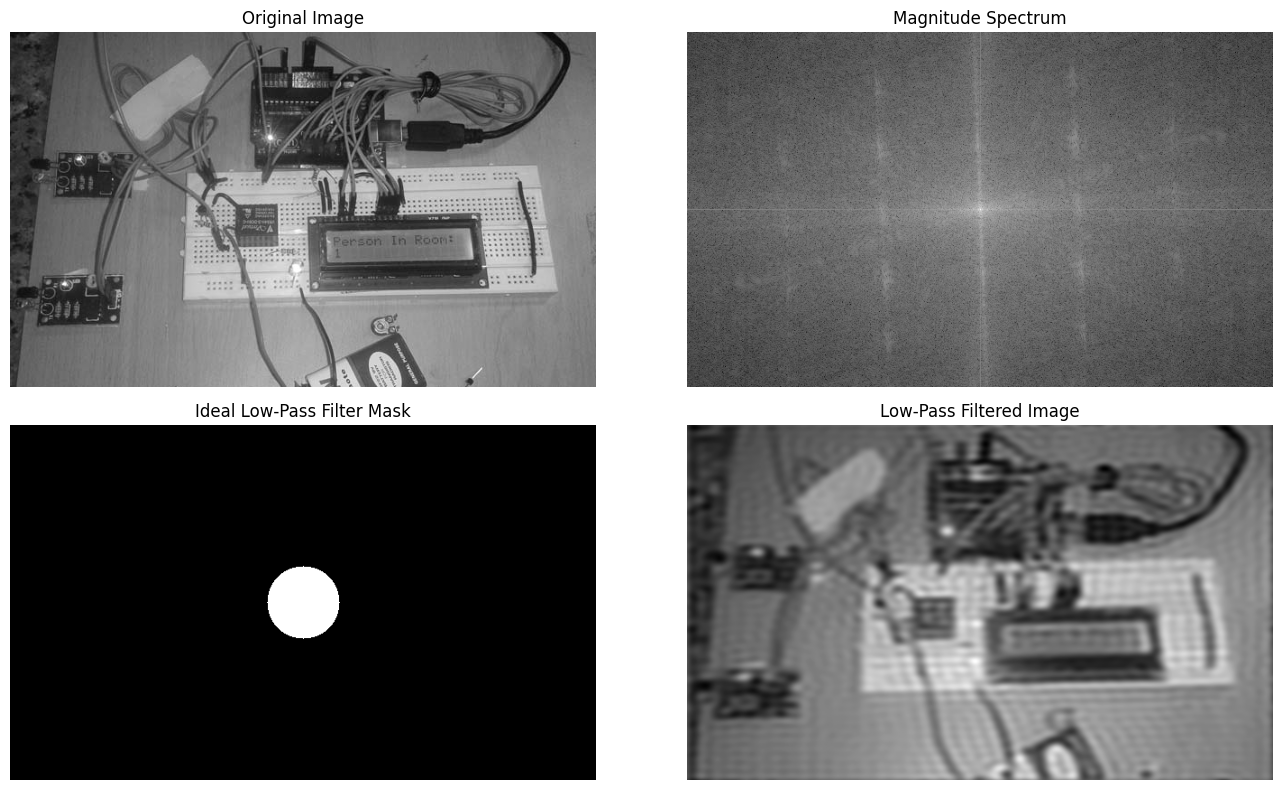

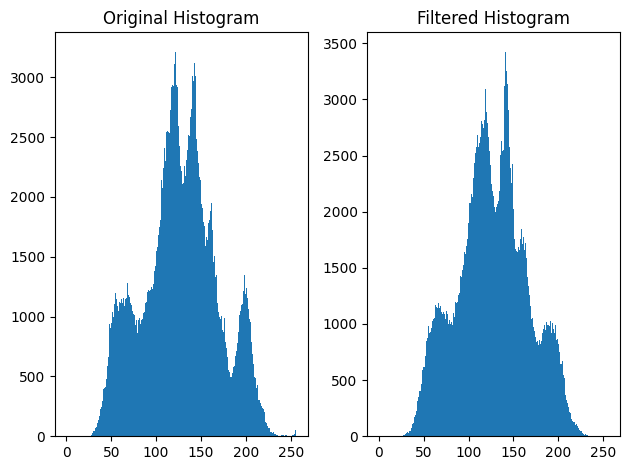

Ideal Low-Pass Filter
----------------------
Cut-off Radius = 40 pixels


In [ ]:
# Experiment 9
# Frequency Domain Low-Pass Filter

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Upload Image
# -----------------------------
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Read image as grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# -----------------------------
# Fourier Transform
# -----------------------------
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Magnitude Spectrum
magnitude = 20 * np.log(np.abs(dft_shift) + 1)

# -----------------------------
# Create Ideal Low-Pass Filter
# -----------------------------
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

mask = np.zeros((rows, cols), np.uint8)

radius = 40   # Cut-off frequency

for i in range(rows):
    for j in range(cols):
        if (i - crow) ** 2 + (j - ccol) ** 2 <= radius ** 2:
            mask[i, j] = 1

# Apply mask
filtered_dft = dft_shift * mask

# -----------------------------
# Inverse Fourier Transform
# -----------------------------
inverse_shift = np.fft.ifftshift(filtered_dft)
inverse_img = np.fft.ifft2(inverse_shift)
filtered_image = np.abs(inverse_img)

filtered_image = np.clip(filtered_image, 0, 255).astype(np.uint8)

# -----------------------------
# Display Images
# -----------------------------
plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(mask, cmap='gray')
plt.title("Ideal Low-Pass Filter Mask")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(filtered_image, cmap='gray')
plt.title("Low-Pass Filtered Image")
plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------
# Histograms
# -----------------------------

plt.subplot(1,2,1)
plt.hist(img.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(filtered_image.ravel(), bins=256, range=[0,256])
plt.title("Filtered Histogram")

plt.tight_layout()
plt.show()

print("Ideal Low-Pass Filter")
print("----------------------")
print("Cut-off Radius =", radius, "pixels")

Saving 3640322279678e635c3303f83c090769.jpg to 3640322279678e635c3303f83c090769 (3).jpg


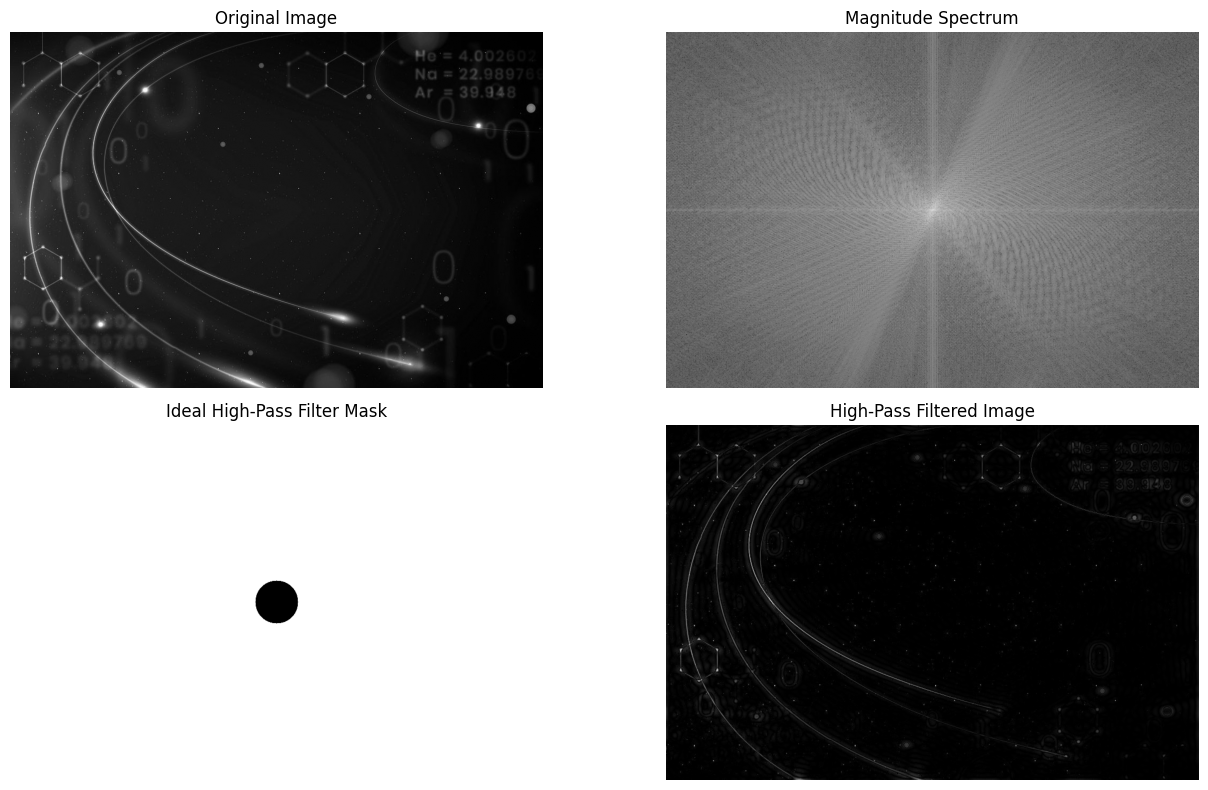

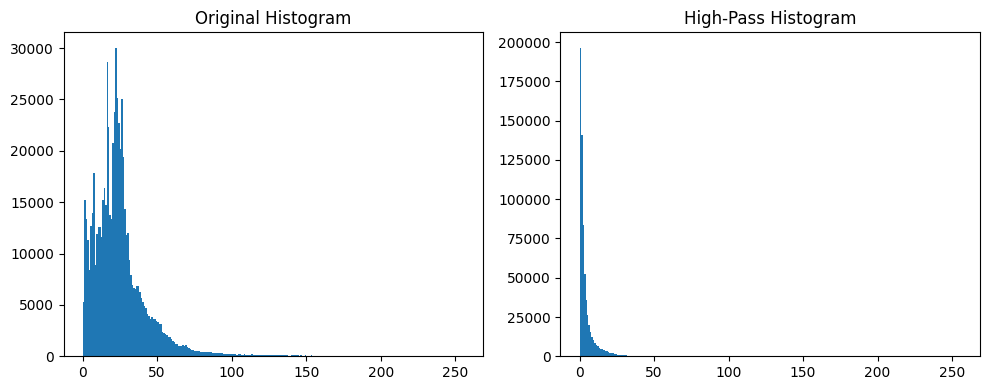

Ideal High-Pass Filter
----------------------
Cut-off Radius = 40 pixels


In [ ]:
# Experiment 10
# Frequency Domain High-Pass Filter

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Upload Image
# -----------------------------
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Read image as grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# -----------------------------
# Fourier Transform
# -----------------------------
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Magnitude Spectrum
magnitude = 20 * np.log(np.abs(dft_shift) + 1)

# -----------------------------
# Create Ideal High-Pass Filter
# -----------------------------
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

mask = np.ones((rows, cols), np.uint8)

radius = 40   # Cut-off frequency

for i in range(rows):
    for j in range(cols):
        if (i - crow) ** 2 + (j - ccol) ** 2 <= radius ** 2:
            mask[i, j] = 0

# Apply mask
filtered_dft = dft_shift * mask

# -----------------------------
# Inverse Fourier Transform
# -----------------------------
inverse_shift = np.fft.ifftshift(filtered_dft)
inverse_img = np.fft.ifft2(inverse_shift)
filtered_image = np.abs(inverse_img)

filtered_image = np.clip(filtered_image, 0, 255).astype(np.uint8)

# -----------------------------
# Display Images
# -----------------------------
plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(mask, cmap='gray')
plt.title("Ideal High-Pass Filter Mask")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(filtered_image, cmap='gray')
plt.title("High-Pass Filtered Image")
plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------
# Histograms
# -----------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(img.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(filtered_image.ravel(), bins=256, range=[0,256])
plt.title("High-Pass Histogram")

plt.tight_layout()
plt.show()

print("Ideal High-Pass Filter")
print("----------------------")
print("Cut-off Radius =", radius, "pixels")

Saving 8688974d8eb70cbc521a4af64e0d927b.jpg to 8688974d8eb70cbc521a4af64e0d927b (1).jpg


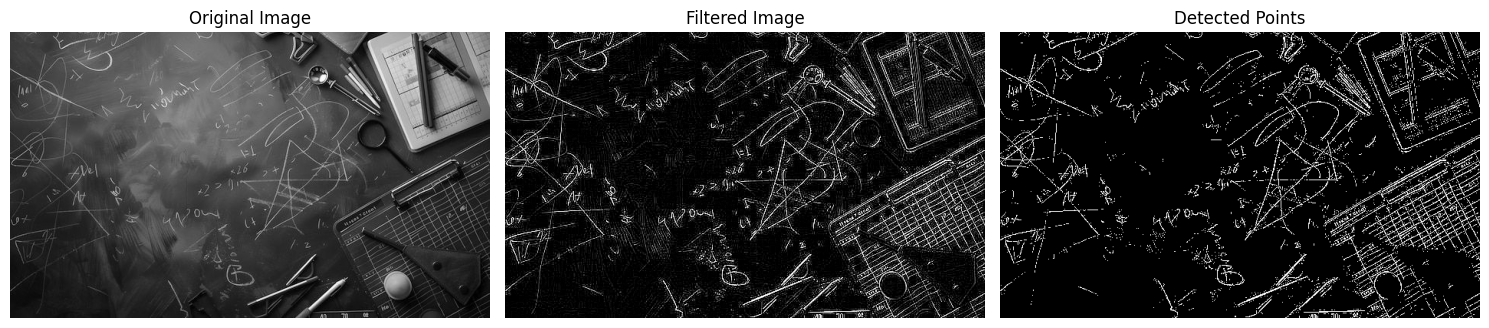

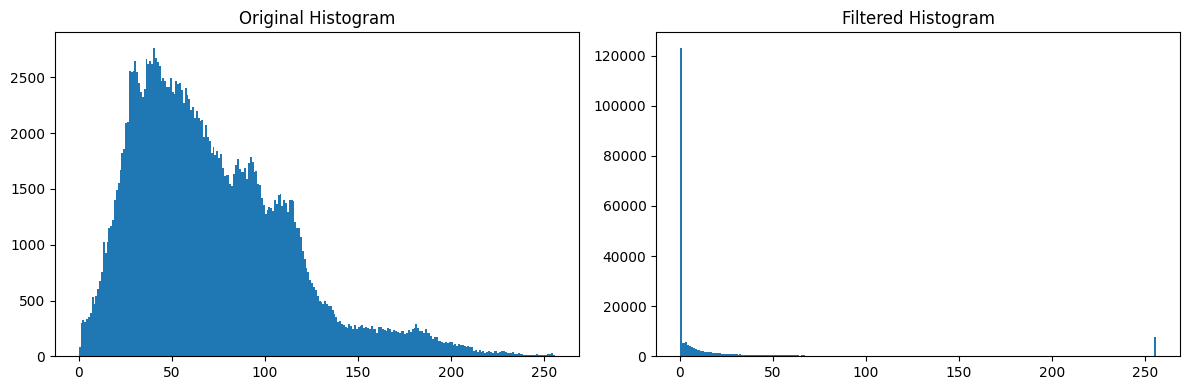

Point Detection Mask:
[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]

Threshold Used: 120


In [ ]:
# Experiment 11
# Point Detection Using Spatial Filtering

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Upload Image
# -----------------------------
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Point Detection Mask
# -----------------------------
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

# Apply filter
filtered = cv2.filter2D(gray, -1, kernel)

# -----------------------------
# Threshold the result
# -----------------------------
threshold = 120

_, detected_points = cv2.threshold(filtered, threshold, 255, cv2.THRESH_BINARY)

# -----------------------------
# Display Images
# -----------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(filtered, cmap='gray')
plt.title("Filtered Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(detected_points, cmap='gray')
plt.title("Detected Points")
plt.axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# Histograms
# -----------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(filtered.ravel(), bins=256, range=[0,256])
plt.title("Filtered Histogram")

plt.tight_layout()
plt.show()

# -----------------------------
# Display Kernel
# -----------------------------
print("Point Detection Mask:")
print(kernel)

print("\nThreshold Used:", threshold)